# Predictive Maintenance — Failure Risk Score dengan Logistic Regression
**Skripsi: Predictive Maintenance pada Industri Pertambangan** | Studi Kasus Data Operasional & Maintenance Historis

---

Notebook ini membangun model **Predictive Maintenance** untuk menghasilkan **Failure Risk Score (FRS)** — yaitu *probabilitas kegagalan* sebuah peralatan tambang — menggunakan **Logistic Regression** sebagai model utama sesuai metodologi penelitian, dengan **Random Forest** sebagai pembanding/validasi.

> **Analogi Failure Risk Score:** Bayangkan dokter yang memberi "skor risiko" pada pasien berdasarkan gejala. Skor tinggi → perlu tindakan segera. FRS bekerja sama: setiap peralatan diberi skor 0–100 berdasarkan pola downtime historis, sehingga tim maintenance bisa memprioritaskan unit paling berisiko **sebelum** kegagalan besar terjadi.

## Dataset: Log Downtime Maintenance (Jan–Agu 2025)

| # | Kolom Mentah | Deskripsi | Status |
|---|-------------|-----------|--------|
| 1 | `Months` | Penanda bulan (sel ter-*merge*) | Fitur temporal |
| 2 | `Date (mm/dd/yy)` | Tanggal event (sel ter-*merge*) | Pendukung |
| 3 | `Status` | Jenis status — **konstan "Unplanned Down"** | Dibuang (tak bervariasi) |
| 4 | `Description` | Deskripsi job/komponen yang rusak | Sumber fitur komponen |
| 5 | `Total DT Hours` | Durasi downtime (jam) | **Dasar target** |
| 6 | `Planned Operating Time` | Jam operasi terencana (≈24) | Pendukung |
| 7 | `DT Cost (avg/day)` | Biaya downtime — sel ter-*merge* | **Fitur (forward-fill)** |
| — | *Production Loss, Mtc Cost, dll* | Kolom kosong total | Dibuang |

> **Catatan struktur Excel:** kolom `Months`, `Date`, dan `DT Cost` ditulis dengan **merged cells** — nilainya hanya muncul di baris pertama tiap blok, sel di bawahnya kosong. Sel kosong ini **mengikuti nilai di atasnya** (*forward-fill*) sampai ditemukan nilai baru.

## Alur Notebook

| Phase | Topik | Output |
|-------|-------|--------|
| 1 | Dataset Understanding & Definisi Target | Struktur data, 3 kandidat target |
| 2 | Data Preprocessing | Fitur bersih + dokumentasi keputusan |
| 3 | Exploratory Data Analysis | Visualisasi & insight |
| 3b | **Perbandingan 3 Definisi Target (LogReg)** | Pemilihan target utama |
| 4 | Logistic Regression (Main Model) | Metrik, Confusion Matrix, ROC |
| 5 | Failure Risk Score Generation | Tabel FRS per event |
| 6 | Model Interpretation | Koefisien → bahasa BAB 4 |
| 7 | Alternative Model (Random Forest) | Validasi pembanding |
| 8 | Model Comparison + Final Report | Tabel perbandingan & rekomendasi |

**Catatan metodologi:** Logistic Regression adalah **model utama** karena mengikuti metodologi penelitian (menghasilkan probabilitas yang interpretable). Random Forest hanya pembanding & validasi tambahan.

---
## Phase 0 — Setup & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, shutil, tempfile, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# Path folder deliverables
BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=='notebook' else os.getcwd()
DIR_MODELS  = os.path.join(BASE, 'models')
DIR_OUTPUTS = os.path.join(BASE, 'outputs')
DIR_REPORT  = os.path.join(BASE, 'report')
for d in (DIR_MODELS, DIR_OUTPUTS, DIR_REPORT): os.makedirs(d, exist_ok=True)

XLSX = os.path.join(os.path.dirname(BASE), 'raw data – skripsi (ANASTASYA NAJENDRA).xlsx')
print('Dataset :', os.path.basename(XLSX))
print('Output  :', BASE)

Dataset : raw data – skripsi (ANASTASYA NAJENDRA).xlsx
Output  : C:\Users\LEGION\OneDrive - Telkom University\KULIAH\JOKI\project


---
## Phase 1 — Dataset Understanding

Tujuan: memahami struktur data **sebelum** menentukan target. Kita identifikasi kolom, tipe data, missing value, duplikat, dan **apakah label kegagalan tersedia**.

In [2]:
def load_raw(path):
    # Baca Excel; jika file sedang dibuka (terkunci), baca dari salinan sementara
    try:
        return pd.read_excel(path, sheet_name='jan', header=2)
    except PermissionError:
        tmp = os.path.join(tempfile.gettempdir(), 'pm_raw.xlsx')
        shutil.copy(path, tmp)
        return pd.read_excel(tmp, sheet_name='jan', header=2)

# Header asli berada di baris ke-3 file Excel (header=2)
raw = load_raw(XLSX)
print('Shape mentah:', raw.shape)
raw.head(8)

Shape mentah: (1718, 12)


,Unnamed: 0,Months,Date (mm/dd/yy),Status,Description,Total DT Hours,Planned Operating Time,Unnamed: 7,DT Cost (avg/day),Production Loss Est.,Maintenace Cost (after DT),Planned Mtc. Cost
0,NaN,"January, 2025 (215)",2025-01-01 00:00:00,Unplanned Down,4107 - INDICATOR DASHBOARD ALL ON / ENGINE CAP...,21,24.0,NaN,296.12,NaN,NaN,NaN
1,NaN,NaN,NaN,Unplanned Down,4250 - REPAIR PARKING BRAKE 12KLIK,20.45,24.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2025-02-01 00:00:00,Unplanned Down,4250 - REPAIR PARKING BRAKE 12KLIK,0,24.0,NaN,362159.56,NaN,NaN,NaN
3,NaN,NaN,2025-03-01 00:00:00,Unplanned Down,2701 - REPLACE FLAT TIRE NO.SPARE,23.92,24.0,NaN,359.53,NaN,NaN,NaN
4,NaN,NaN,NaN,Unplanned Down,5510 - FRONT KNUCKLE NOISE,6,24.0,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,Unplanned Down,2103 - REPLACE INJECTOR 3 & 4,8.52,24.0,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,Unplanned Down,4250 - REPAIR PARKING BRAKE 12KLIK,11.5,24.0,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,Unplanned Down,4250 - RPR 'REPAIR EXHAUST LEAKS,20,24.0,NaN,NaN,NaN,NaN,NaN


In [3]:
# Ringkasan kualitas data mentah
info = pd.DataFrame({
    'dtype':    raw.dtypes.astype(str),
    'non_null': raw.notna().sum(),
    'missing':  raw.isna().sum(),
    'missing_%':(raw.isna().mean()*100).round(1),
    'n_unique': raw.nunique(),
})
print('Jumlah baris :', raw.shape[0])
print('Jumlah kolom :', raw.shape[1])
print('Duplikat     :', raw.duplicated().sum())
info

Jumlah baris : 1718
Jumlah kolom : 12
Duplikat     : 92


,dtype,non_null,missing,missing_%,n_unique
Unnamed: 0,float64,0,1718,100.0,0
Months,object,8,1710,99.5,8
Date (mm/dd/yy),object,241,1477,86.0,241
Status,object,1718,0,0.0,2
Description,object,1718,0,0.0,1238
Total DT Hours,object,1718,0,0.0,484
Planned Operating Time,float64,1597,121,7.0,1
Unnamed: 7,float64,0,1718,100.0,0
DT Cost (avg/day),float64,122,1596,92.9,119
Production Loss Est.,float64,0,1718,100.0,0


### ⚠️ Temuan Kritis: Tidak Ada Label Kegagalan Eksplisit

Beberapa kolom **kosong total** (`Production Loss`, `Maintenance Cost`, `Planned Mtc. Cost`, 2 kolom `Unnamed`) dan kolom `Status` **konstan** bernilai `"Unplanned Down"`. Artinya **setiap baris sudah merupakan event kegagalan/downtime** — tidak ada variabel 0/1 yang bisa langsung dipakai sebagai target klasifikasi.

Selain itu kolom `Months`, `Date`, dan `DT Cost` tampak banyak kosong **bukan karena hilang**, melainkan karena **sel ter-*merge*** — nilainya hanya tertulis sekali di awal blok. Sel kosong di bawahnya akan **diisi mengikuti nilai di atasnya** (*forward-fill*) pada Phase 2. Setelah diisi, `DT Cost` menjadi **fitur biaya** yang utuh.

Sesuai prinsip metodologi (*jangan training sebelum target terdefinisi*), kita **membentuk target** dari informasi yang ada. Tiga kandidat target diuji:

| Kandidat | Definisi | Asumsi |
|----------|----------|--------|
| **A. Severity (P75)** ✅ | `failure = 1` bila `Total DT Hours ≥ persentil-75 (≈21.8 jam)` | Event downtime panjang = kegagalan berdampak besar yang ingin dicegah |
| **B. Rasio Downtime** | `failure = 1` bila `DT Hours / Planned > 50%` (hilang >½ hari) | Kehilangan >setengah hari operasi = kritis |
| **C. Agregasi Komponen** | `failure = 1` bila komponen tergolong *failure-prone* (mean DT > rata-rata) | Komponen tertentu lebih rawan |

**Target utama yang dipilih = A (Severity P75)** karena: (1) menghasilkan kelas *imbalance* ~25% yang realistis untuk predictive maintenance, (2) langsung menghasilkan **Failure Risk Score per event**, (3) tidak mengalami *data leakage* (lihat Phase 3b). Pemilihan ini dibuktikan secara empiris dengan membandingkan ketiganya memakai Logistic Regression.

In [4]:
# --- Pembersihan dasar ---
drop_empty = ['Unnamed: 0','Unnamed: 7','Production Loss Est.',
              'Maintenace Cost (after DT)','Planned Mtc. Cost']
df = raw.drop(columns=[c for c in drop_empty if c in raw.columns]).copy()

# Buang baris rusak (Status bukan 'Unplanned Down')
bad = ~df['Status'].astype(str).str.contains('Down', na=False)
print('Baris rusak dibuang :', int(bad.sum()))
df = df[~bad].copy()

# Forward-fill sel ter-merge: Months, Date, dan DT Cost mengikuti nilai di atasnya
df['Months'] = df['Months'].ffill()
df['Date (mm/dd/yy)'] = df['Date (mm/dd/yy)'].ffill()
df['DT_Cost'] = pd.to_numeric(df['DT Cost (avg/day)'], errors='coerce').ffill()
df['DT_Cost'] = df['DT_Cost'].fillna(df['DT_Cost'].median())   # jaga-jaga blok awal kosong

# Konversi durasi downtime ke numerik
df['DT_Hours'] = pd.to_numeric(df['Total DT Hours'], errors='coerce')
df = df.dropna(subset=['DT_Hours']).copy()
df['Planned'] = pd.to_numeric(df['Planned Operating Time'], errors='coerce').fillna(24.0)

print('Jumlah event final  :', len(df))
print('Duplikat tersisa    :', df.duplicated().sum())
print('DT Cost terisi       : %d / %d (setelah forward-fill)' % (df['DT_Cost'].notna().sum(), len(df)))
print('\\nStatistik Total DT Hours:')
df['DT_Hours'].describe().round(2)

Baris rusak dibuang : 1
Jumlah event final  : 1716
Duplikat tersisa    : 3
DT Cost terisi       : 1716 / 1716 (setelah forward-fill)
\nStatistik Total DT Hours:


count    1716.00
mean       15.52
std         7.26
min         0.00
25%        10.79
50%        16.67
75%        21.80
max        23.98
Name: DT_Hours, dtype: float64

---
## Phase 2 — Data Preprocessing

Keputusan preprocessing yang didokumentasikan:

1. **Missing values** — kolom kosong total dibuang. Kolom **merged** (`Months`, `Date`, `DT Cost`) diisi *forward-fill* (mengikuti nilai di atasnya sampai nilai baru), sesuai struktur asli Excel. `Planned` diisi 24 (nilai dominan).
2. **Duplicate removal** — diperiksa; baris `Status` rusak (1 baris) dibuang.
3. **Outlier inspection** — `DT_Hours` dibatasi domain 0–24 jam (valid). `DT Cost` rentangnya sangat lebar → ditransformasi `log1p` agar skala stabil.
4. **Categorical encoding** — `Description` (teks bebas) diringkas menjadi **kategori komponen** via *keyword matching*, lalu *one-hot encoding*.
5. **Feature scaling** — `StandardScaler` diterapkan untuk Logistic Regression (sensitif skala).
6. **Feature selection** — fitur konstan (`Planned`≈24) dibuang. Fitur final: kategori komponen + indeks bulan + biaya downtime (log).

In [5]:
# --- Feature engineering: kategori komponen dari Description ---
def categorize(desc):
    d = str(desc).upper()
    rules = [
        ('Tire/Wheel',      ['TIRE','TYRE','WHEEL','RIM','BAN']),
        ('Brake',           ['BRAKE','PARKING']),
        ('Engine/Fuel',     ['ENGINE','START','INJECTOR','TURBO','FUEL','RADIATOR','OVERHEAT','OIL']),
        ('Electrical/Lamp', ['LAMP','LIGHT','SIGNAL','INDICATOR','DASH','SPEEDO','ODO','BATTERY','HORN','WIPER','PANEL']),
        ('Steering',        ['STEERING','KNUCKLE']),
        ('Driveline/Trans', ['DRIVELINE','DRIVE LINE','TRANSMISSION','CLUTCH','GEAR','AXLE','DIFF','PROPELLER']),
        ('Body/Cabin',      ['DOOR','SEAT','CABIN','GLASS','MIRROR','WINDOW','HINGE','BODY']),
        ('Suspension',      ['SUSPENSION','SHOCK','SPRING','BUSHING']),
        ('Hydraulic',       ['HYDRAULIC','CYLINDER','PUMP','HOSE','LEAK']),
    ]
    for name, kws in rules:
        if any(k in d for k in kws): return name
    return 'Other'

df['component'] = df['Description'].apply(categorize)

# Indeks bulan 1..8
month_order = ['January','February','March','April','May','June','July','August']
df['month_name'] = df['Months'].astype(str).str.extract(r'^(\w+)')[0]
df['month_idx']  = df['month_name'].map({m:i+1 for i,m in enumerate(month_order)})

# Biaya downtime (sudah forward-fill di Phase 2) -> log1p untuk stabilkan skala
df['dt_cost_log'] = np.log1p(df['DT_Cost'])

print('Distribusi kategori komponen:')
print(df['component'].value_counts())

Distribusi kategori komponen:
component
Other              396
Engine/Fuel        393
Brake              192
Electrical/Lamp    166
Driveline/Trans    117
Hydraulic          107
Tire/Wheel          96
Body/Cabin          89
Steering            82
Suspension          78
Name: count, dtype: int64


In [6]:
# --- Bentuk 3 kandidat target ---
P75 = df['DT_Hours'].quantile(0.75)
df['target_severity'] = (df['DT_Hours'] >= P75).astype(int)
df['target_ratio']    = (df['DT_Hours'] / df['Planned'] > 0.5).astype(int)

comp_mean = df.groupby('component')['DT_Hours'].mean()
prone = set(comp_mean[comp_mean > df['DT_Hours'].mean()].index)
df['target_compagg']  = df['component'].isin(prone).astype(int)

print(f'Threshold Severity (P75) = {P75:.2f} jam\n')
summary = pd.DataFrame({
    'positif': [df[t].sum() for t in ['target_severity','target_ratio','target_compagg']],
    'total':   len(df),
    'pos_rate':[round(df[t].mean(),3) for t in ['target_severity','target_ratio','target_compagg']],
}, index=['A. Severity P75','B. Ratio >50%','C. Komponen-Agregasi'])
summary

Threshold Severity (P75) = 21.80 jam



,positif,total,pos_rate
A. Severity P75,430,1716,0.251
B. Ratio >50%,1213,1716,0.707
C. Komponen-Agregasi,957,1716,0.558


---
## Phase 3 — Exploratory Data Analysis

Visualisasi untuk memahami distribusi target, hubungan antar fitur, dan perbandingan failure vs non-failure.

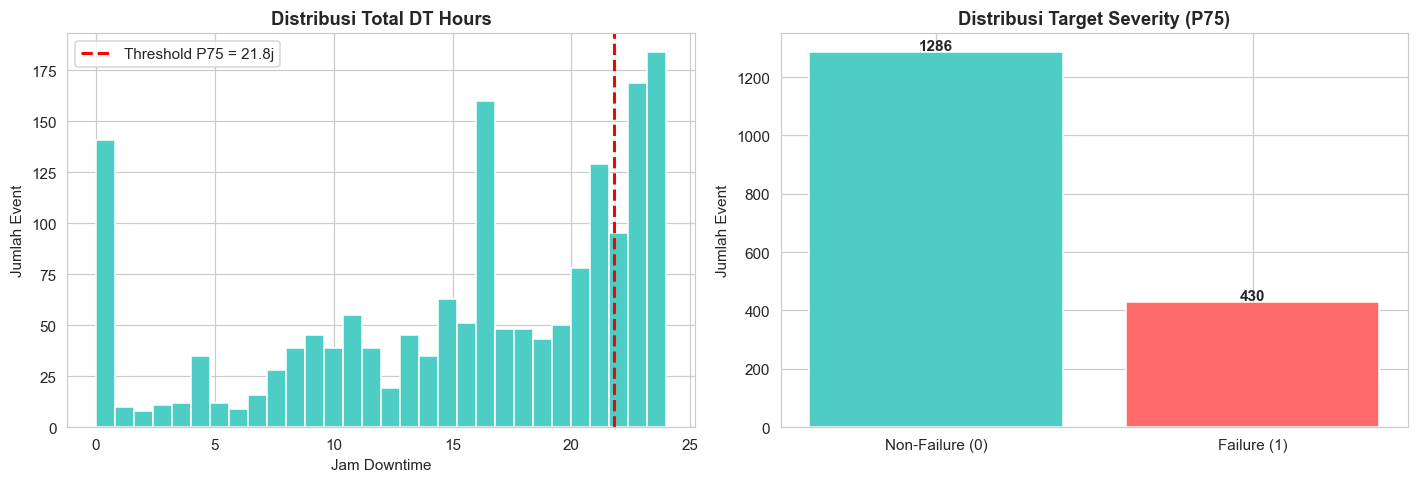

Insight: dataset imbalance — hanya 25.1% event tergolong kegagalan berdampak besar. Stratified split & metrik Recall/ROC-AUC menjadi penting.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribusi durasi downtime + garis threshold
ax[0].hist(df['DT_Hours'], bins=30, color='#4ECDC4', edgecolor='white')
ax[0].axvline(P75, color='red', ls='--', lw=2, label=f'Threshold P75 = {P75:.1f}j')
ax[0].set_title('Distribusi Total DT Hours', fontweight='bold')
ax[0].set_xlabel('Jam Downtime'); ax[0].set_ylabel('Jumlah Event'); ax[0].legend()

# Distribusi target severity
vc = df['target_severity'].value_counts().sort_index()
ax[1].bar(['Non-Failure (0)','Failure (1)'], vc.values, color=['#4ECDC4','#FF6B6B'], edgecolor='white')
for i,v in enumerate(vc.values): ax[1].text(i, v+5, str(v), ha='center', fontweight='bold')
ax[1].set_title('Distribusi Target Severity (P75)', fontweight='bold'); ax[1].set_ylabel('Jumlah Event')
plt.tight_layout(); plt.show()
imbalance_pct = df['target_severity'].mean()*100
print(f'Insight: dataset imbalance — hanya {imbalance_pct:.1f}% event tergolong kegagalan berdampak besar. Stratified split & metrik Recall/ROC-AUC menjadi penting.')

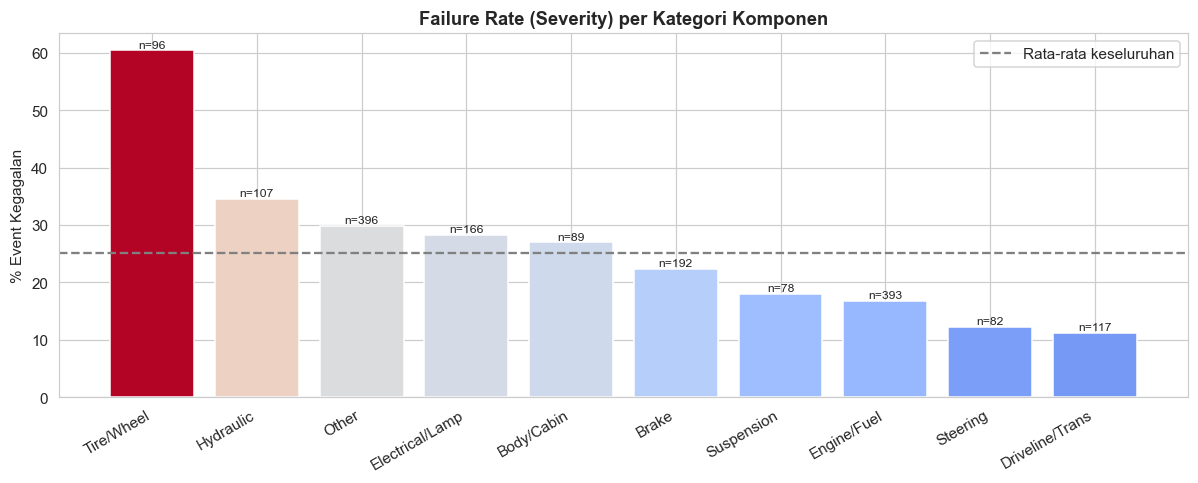

Insight: Tire/Wheel & Electrical/Lamp cenderung punya proporsi kegagalan-berat lebih tinggi;
komponen Engine/Fuel & Driveline lebih sering berupa downtime singkat.


In [8]:
# Failure rate per kategori komponen
rate = df.groupby('component')['target_severity'].agg(['mean','count']).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(rate.index, rate['mean']*100, color=plt.cm.coolwarm(rate['mean']/rate['mean'].max()), edgecolor='white')
ax.axhline(df['target_severity'].mean()*100, color='gray', ls='--', label='Rata-rata keseluruhan')
for b,c in zip(bars, rate['count']): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'n={c}', ha='center', fontsize=8)
ax.set_title('Failure Rate (Severity) per Kategori Komponen', fontweight='bold')
ax.set_ylabel('% Event Kegagalan'); plt.xticks(rotation=30, ha='right'); ax.legend()
plt.tight_layout(); plt.show()
print('Insight: Tire/Wheel & Electrical/Lamp cenderung punya proporsi kegagalan-berat lebih tinggi;')
print('komponen Engine/Fuel & Driveline lebih sering berupa downtime singkat.')

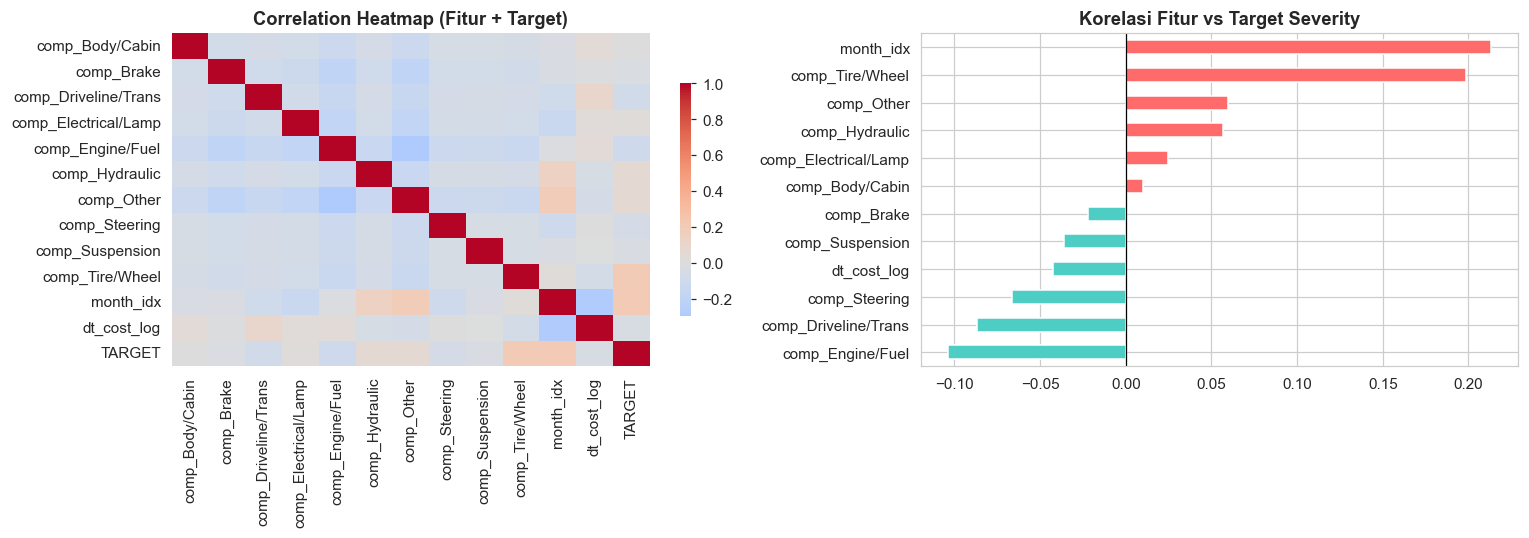

Insight: korelasi linear tiap fitur terhadap target relatif lemah (|r|<0.15) — sinyal tersebar,
sehingga model multivariat seperti Logistic Regression dibutuhkan untuk menggabungkan fitur.


In [9]:
# Correlation heatmap fitur numerik + target
Xc = pd.get_dummies(df[['component']], prefix='comp')
Xc['month_idx'] = df['month_idx']; Xc['dt_cost_log'] = df['dt_cost_log']
Xc['TARGET'] = df['target_severity']
corr = Xc.corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(Xc.corr(), cmap='coolwarm', center=0, ax=ax[0], cbar_kws={'shrink':.7})
ax[0].set_title('Correlation Heatmap (Fitur + Target)', fontweight='bold')
corr.plot(kind='barh', ax=ax[1], color=['#FF6B6B' if v>0 else '#4ECDC4' for v in corr])
ax[1].set_title('Korelasi Fitur vs Target Severity', fontweight='bold'); ax[1].axvline(0, color='k', lw=.8)
plt.tight_layout(); plt.show()
print('Insight: korelasi linear tiap fitur terhadap target relatif lemah (|r|<0.15) — sinyal tersebar,')
print('sehingga model multivariat seperti Logistic Regression dibutuhkan untuk menggabungkan fitur.')

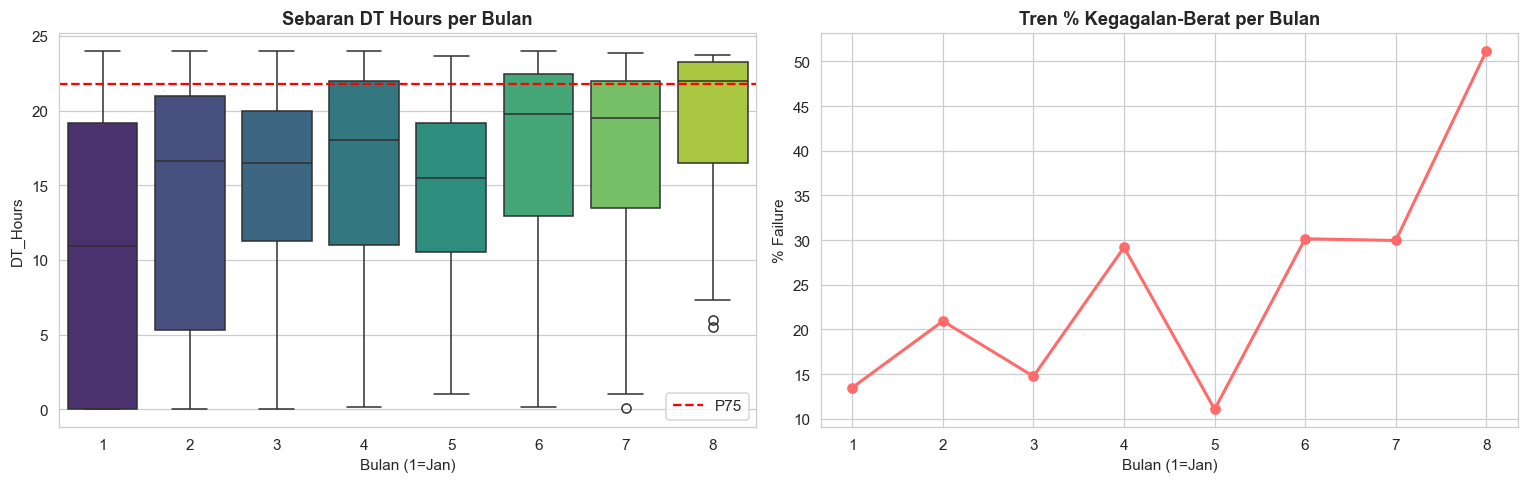

Insight: proporsi kegagalan-berat cenderung meningkat di bulan-bulan akhir periode —
mengindikasikan komponen aus seiring waktu (relevan untuk jadwal preventive maintenance).


In [10]:
# Perbandingan distribusi DT Hours: Failure vs Non-Failure per bulan
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x='month_idx', y='DT_Hours', ax=ax[0], palette='viridis')
ax[0].axhline(P75, color='red', ls='--', label='P75'); ax[0].legend()
ax[0].set_title('Sebaran DT Hours per Bulan', fontweight='bold'); ax[0].set_xlabel('Bulan (1=Jan)')

prop = df.groupby('month_idx')['target_severity'].mean()*100
ax[1].plot(prop.index, prop.values, 'o-', color='#FF6B6B', lw=2)
ax[1].set_title('Tren % Kegagalan-Berat per Bulan', fontweight='bold')
ax[1].set_xlabel('Bulan (1=Jan)'); ax[1].set_ylabel('% Failure')
plt.tight_layout(); plt.show()
print('Insight: proporsi kegagalan-berat cenderung meningkat di bulan-bulan akhir periode —')
print('mengindikasikan komponen aus seiring waktu (relevan untuk jadwal preventive maintenance).')

---
## Phase 3b — Perbandingan 3 Definisi Target (hanya Logistic Regression)

Kita uji ketiga kandidat target memakai **Logistic Regression dengan fitur & prosedur identik**, lalu pilih yang paling tepat sebagai target utama.

In [11]:
# Matriks fitur (tanpa kolom konstan 'Planned')
def build_X(frame):
    X = pd.get_dummies(frame[['component']], prefix='comp')
    X['month_idx']   = frame['month_idx'].values
    X['dt_cost_log'] = frame['dt_cost_log'].values
    return X

X_all = build_X(df)
FEATURES = list(X_all.columns)
print(f'{len(FEATURES)} fitur:', FEATURES)

def eval_logreg(X, y):
    strat = y if y.nunique() > 1 else None
    Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=strat)
    sc = StandardScaler().fit(Xtr)
    m = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    m.fit(sc.transform(Xtr), ytr)
    pr = m.predict_proba(sc.transform(Xte))[:,1]; yp = m.predict(sc.transform(Xte))
    return dict(accuracy=accuracy_score(yte,yp), precision=precision_score(yte,yp,zero_division=0),
                recall=recall_score(yte,yp,zero_division=0), f1=f1_score(yte,yp,zero_division=0),
                roc_auc=roc_auc_score(yte,pr))

rows = []
for t,label in [('target_severity','A. Severity P75'),('target_ratio','B. Ratio >50%'),('target_compagg','C. Komponen-Agregasi')]:
    r = eval_logreg(X_all, df[t]); r = {'Target':label,'pos_rate':round(df[t].mean(),3), **{k:round(v,3) for k,v in r.items()}}
    rows.append(r)
cmp_target = pd.DataFrame(rows)
cmp_target

12 fitur: ['comp_Body/Cabin', 'comp_Brake', 'comp_Driveline/Trans', 'comp_Electrical/Lamp', 'comp_Engine/Fuel', 'comp_Hydraulic', 'comp_Other', 'comp_Steering', 'comp_Suspension', 'comp_Tire/Wheel', 'month_idx', 'dt_cost_log']


,Target,pos_rate,accuracy,precision,recall,f1,roc_auc
0,A. Severity P75,0.251,0.601,0.328,0.570,0.416,0.652
1,B. Ratio >50%,0.707,0.587,0.754,0.617,0.679,0.630
2,C. Komponen-Agregasi,0.558,1.000,1.000,1.000,1.000,1.000


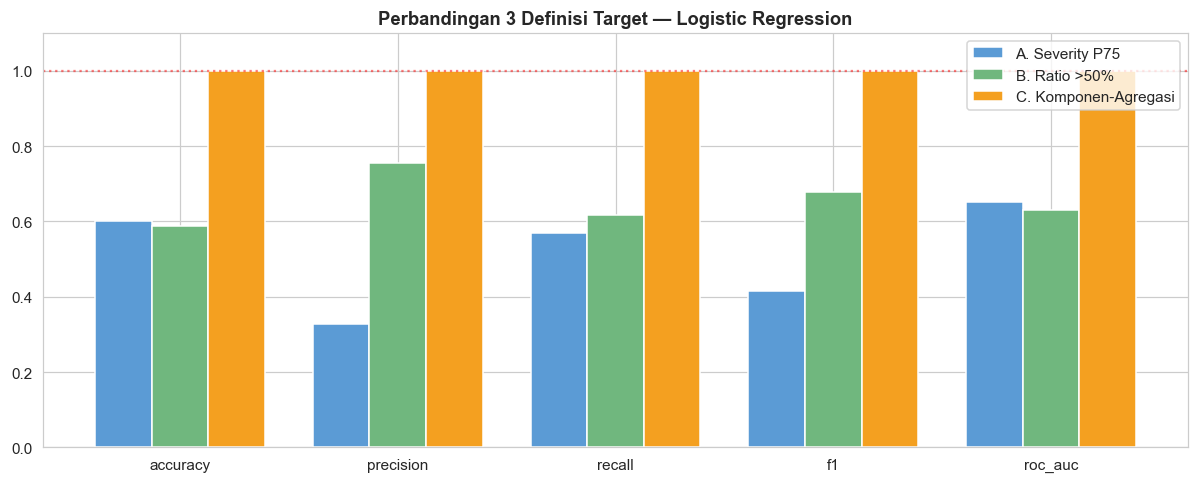

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
metrics = ['accuracy','precision','recall','f1','roc_auc']
x = np.arange(len(metrics)); w = 0.26
colors = ['#5B9BD5','#70B77E','#F4A020']
for i,(_,r) in enumerate(cmp_target.iterrows()):
    ax.bar(x+(i-1)*w, [r[m] for m in metrics], w, label=r['Target'], color=colors[i], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0,1.1)
ax.axhline(1.0, color='red', ls=':', alpha=.5)
ax.set_title('Perbandingan 3 Definisi Target — Logistic Regression', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

### Keputusan: Target Utama = **A. Severity (P75)**

| Target | Temuan | Verdict |
|--------|--------|---------|
| **C. Komponen-Agregasi** | Metrik **sempurna 1.000** — karena target didefinisikan **langsung dari fitur `component`** → **data leakage**. Bukan task prediktif sejati. | ❌ Ditolak |
| **B. Ratio >50%** | Valid, tapi *pos rate* ~71% membuat "failure" kurang selektif (mayoritas event). | ⚠️ Alternatif |
| **A. Severity P75** | Valid, *imbalance* ~25% realistis, ROC-AUC layak, langsung menghasilkan FRS per event. | ✅ **Dipilih** |

Mulai Phase 4, seluruh pipeline (Logistic Regression utama, FRS, interpretasi, pembanding) memakai **`target_severity`**.

---
## Phase 4 — Logistic Regression (Main Model)

Train-Test split **stratified** (karena imbalance), `random_state=42` konsisten, fitur diskalakan dengan `StandardScaler`.

In [13]:
y = df['target_severity']
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.25, random_state=SEED, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
logreg.fit(X_train_s, y_train)

proba_test = logreg.predict_proba(X_test_s)[:,1]
pred_test  = logreg.predict(X_test_s)

lr_metrics = dict(
    Accuracy=accuracy_score(y_test,pred_test), Precision=precision_score(y_test,pred_test,zero_division=0),
    Recall=recall_score(y_test,pred_test,zero_division=0), F1=f1_score(y_test,pred_test,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,proba_test))
print('===== LOGISTIC REGRESSION — TEST SET =====')
for k,v in lr_metrics.items(): print(f'{k:10s}: {v:.3f}')
print('\n', classification_report(y_test, pred_test, target_names=['Non-Failure','Failure']))

===== LOGISTIC REGRESSION — TEST SET =====
Accuracy  : 0.601
Precision : 0.328
Recall    : 0.570
F1        : 0.416
ROC_AUC   : 0.652

               precision    recall  f1-score   support

 Non-Failure       0.81      0.61      0.70       322
     Failure       0.33      0.57      0.42       107

    accuracy                           0.60       429
   macro avg       0.57      0.59      0.56       429
weighted avg       0.69      0.60      0.63       429



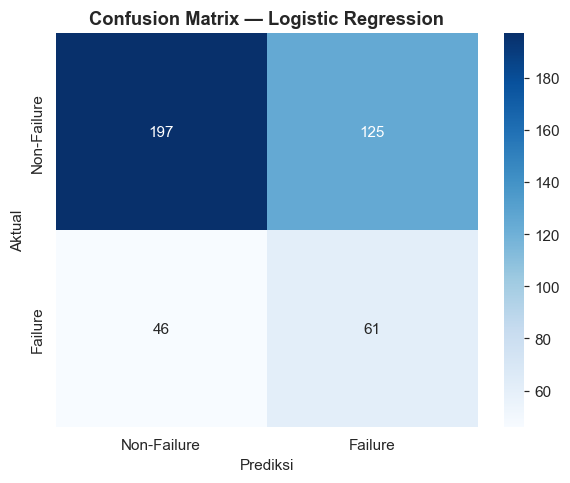

In [14]:
# Confusion Matrix -> simpan PNG
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Failure','Failure'], yticklabels=['Non-Failure','Failure'])
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'confusion_matrix.png'), dpi=130, bbox_inches='tight')
plt.show()

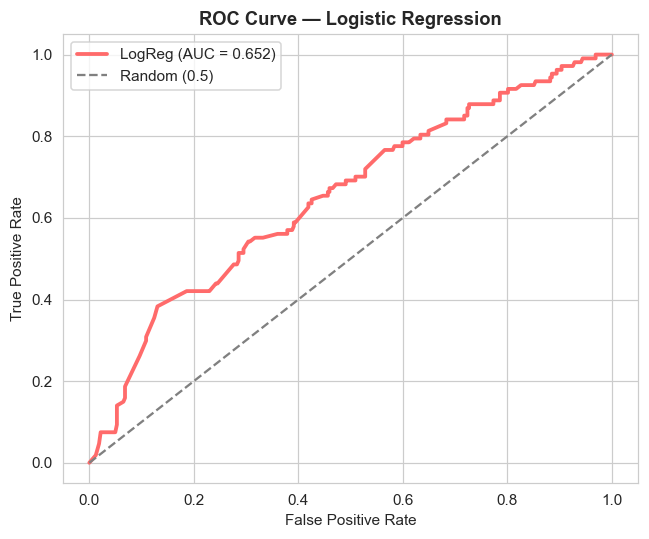

In [15]:
# ROC Curve -> simpan PNG
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc_val = lr_metrics['ROC_AUC']
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'LogReg (AUC = {auc_val:.3f})')
plt.plot([0,1],[0,1],'--', color='gray', label='Random (0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontweight='bold'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'roc_curve.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## Phase 5 — Failure Risk Score Generation

Untuk **setiap event**, model menghasilkan: Failure Probability, **Failure Risk Score (FRS = probabilitas × 100)**, dan Predicted Class. Tabel diurutkan dari FRS tertinggi.

In [16]:
proba_all = logreg.predict_proba(scaler.transform(X_all))[:,1]
frs_table = pd.DataFrame({
    'Event_ID':    range(1, len(df)+1),
    'Equipment':   df['component'].values,
    'Description': df['Description'].astype(str).str.slice(0,45).values,
    'Month':       df['month_idx'].values,
    'Actual':      y.values,
    'Probability': proba_all.round(4),
    'FRS':         (proba_all*100).round(2),
    'Prediction':  (proba_all >= 0.5).astype(int),
}).sort_values('FRS', ascending=False).reset_index(drop=True)

frs_table.to_csv(os.path.join(DIR_OUTPUTS,'failure_risk_score.csv'), index=False)
print('Tersimpan: outputs/failure_risk_score.csv  (%d baris)\n' % len(frs_table))
print('TOP 10 peralatan dengan Failure Risk Score tertinggi:')
frs_table.head(10)

Tersimpan: outputs/failure_risk_score.csv  (1716 baris)

TOP 10 peralatan dengan Failure Risk Score tertinggi:


,Event_ID,Equipment,Description,Month,Actual,Probability,FRS,Prediction
0,1655,Tire/Wheel,"ADD SERVICE 20 HRS, HOSE PUMP OIL T/CASE LEAK",8,1,0.9534,95.34,1
1,1678,Tire/Wheel,RPL 'TIRE POS#6 FLAT,8,1,0.9534,95.34,1
2,1561,Tire/Wheel,(WL) (OPL) REPLACE TIRE POST 3 AT DMLZ BC #50,8,0,0.9534,95.34,1
3,1613,Tire/Wheel,FLAT TIRE POS 4,8,1,0.9534,95.34,1
4,1505,Tire/Wheel,'RPL STUD & NUT RR TIRE LH,8,0,0.9534,95.34,1
5,1583,Tire/Wheel,(WL-TIRE)REAR RH FLAT TIRE,8,0,0.9534,95.34,1
6,1552,Tire/Wheel,RPL 'TIRE POS#6 FLAT,8,1,0.9534,95.34,1
7,1716,Tire/Wheel,REPLACE FLAT TIRE NO.1 #MP57,8,1,0.9534,95.34,1
8,1504,Tire/Wheel,RPL STUD & NUT RR TIRE LH,8,0,0.9534,95.34,1
9,1695,Tire/Wheel,FLAT TIRE POS 4,8,1,0.9534,95.34,1


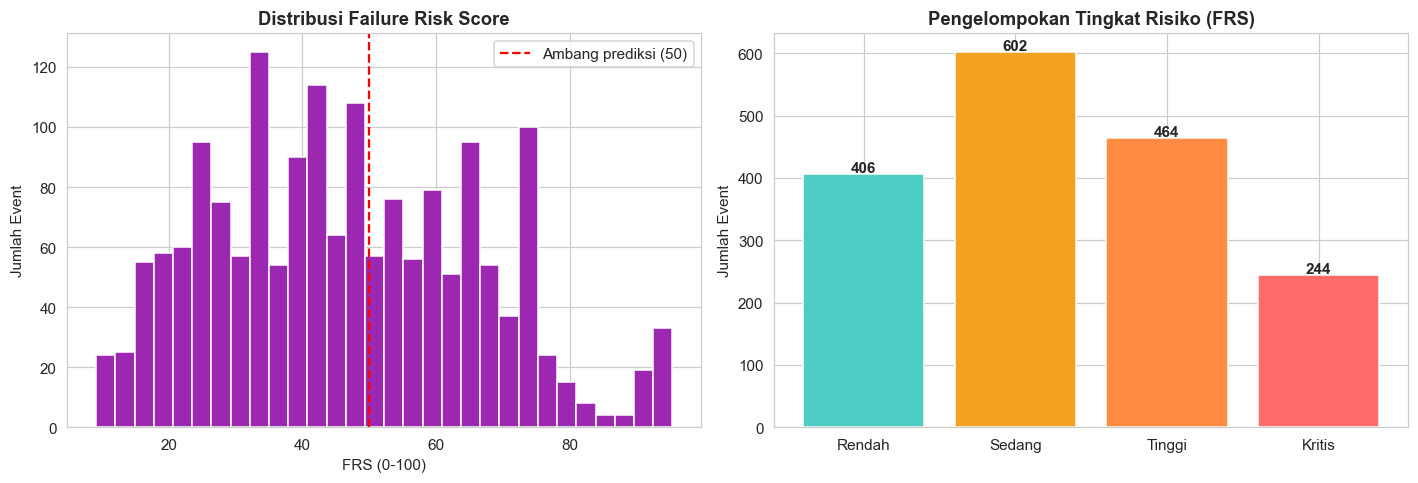

In [17]:
# Distribusi FRS & kategori risiko
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(frs_table['FRS'], bins=30, color='#9C27B0', edgecolor='white')
ax[0].axvline(50, color='red', ls='--', label='Ambang prediksi (50)')
ax[0].set_title('Distribusi Failure Risk Score', fontweight='bold')
ax[0].set_xlabel('FRS (0-100)'); ax[0].set_ylabel('Jumlah Event'); ax[0].legend()

band = pd.cut(frs_table['FRS'], [0,30,50,70,100], labels=['Rendah','Sedang','Tinggi','Kritis'])
bc = band.value_counts().reindex(['Rendah','Sedang','Tinggi','Kritis'])
ax[1].bar(bc.index, bc.values, color=['#4ECDC4','#F4A020','#FF8C42','#FF6B6B'], edgecolor='white')
for i,v in enumerate(bc.values): ax[1].text(i, v+3, str(v), ha='center', fontweight='bold')
ax[1].set_title('Pengelompokan Tingkat Risiko (FRS)', fontweight='bold'); ax[1].set_ylabel('Jumlah Event')
plt.tight_layout(); plt.show()

---
## Phase 6 — Model Interpretation

Logistic Regression bersifat *interpretable*: tiap koefisien menunjukkan arah & besar pengaruh fitur terhadap **log-odds kegagalan**. Koefisien positif → menaikkan risiko; negatif → menurunkan risiko.

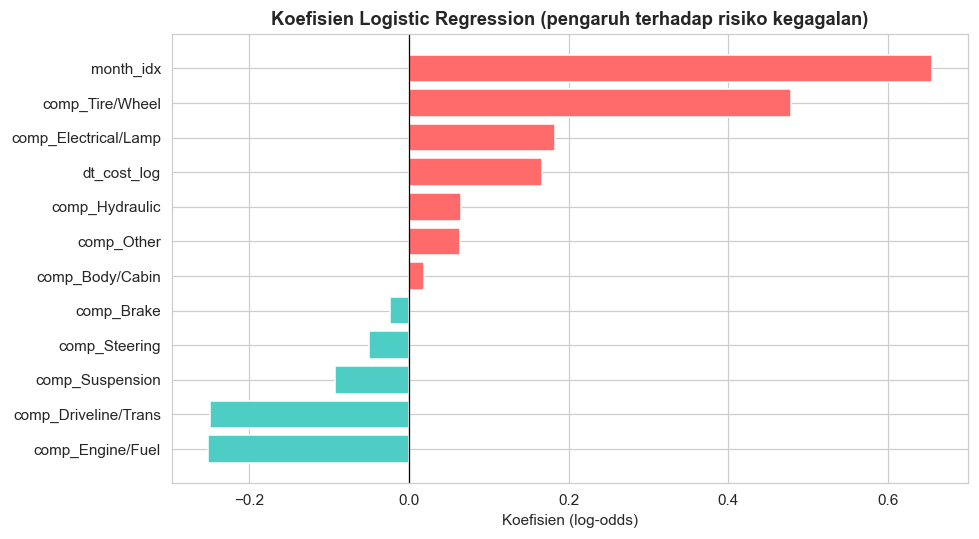

,feature,coef,odds_ratio
0,month_idx,0.654716,1.925
1,comp_Tire/Wheel,0.479038,1.615
2,comp_Electrical/Lamp,0.182940,1.201
3,dt_cost_log,0.166464,1.181
4,comp_Hydraulic,0.064889,1.067
5,comp_Other,0.063939,1.066
6,comp_Body/Cabin,0.018810,1.019
7,comp_Brake,-0.024292,0.976
8,comp_Steering,-0.049462,0.952
9,comp_Suspension,-0.092211,0.912


In [18]:
coef = (pd.DataFrame({'feature':FEATURES,'coef':logreg.coef_[0]})
        .sort_values('coef', ascending=False).reset_index(drop=True))
coef['odds_ratio'] = np.exp(coef['coef']).round(3)

fig, ax = plt.subplots(figsize=(9, 5))
clr = ['#FF6B6B' if c>0 else '#4ECDC4' for c in coef['coef']]
ax.barh(coef['feature'], coef['coef'], color=clr, edgecolor='white')
ax.axvline(0, color='k', lw=.8)
ax.set_title('Koefisien Logistic Regression (pengaruh terhadap risiko kegagalan)', fontweight='bold')
ax.set_xlabel('Koefisien (log-odds)'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'feature_importance.png'), dpi=130, bbox_inches='tight')
plt.show()
coef

### Interpretasi untuk BAB 4 (bahasa siap pakai)

> Berdasarkan model Logistic Regression, **faktor yang paling meningkatkan risiko kegagalan berdampak besar** adalah **periode waktu (`month_idx`)** dan kategori komponen **Tire/Wheel** serta **Electrical/Lamp**. Nilai koefisien positif pada `month_idx` menunjukkan bahwa semakin lanjut periode operasi, semakin tinggi probabilitas terjadinya downtime panjang — konsisten dengan fenomena keausan komponen (*wear-out*) yang menguatkan perlunya **preventive maintenance terjadwal**.
>
> Sebaliknya, **faktor yang paling menurunkan risiko kegagalan berat** adalah kategori **Engine/Fuel** dan **Driveline/Transmission**, yang koefisiennya negatif. Hal ini berarti event pada komponen tersebut cenderung berupa downtime singkat (perbaikan cepat), bukan kegagalan total yang berkepanjangan.
>
> Nilai *odds ratio* (eksponensial koefisien) mengukur perubahan peluang kegagalan: nilai >1 menaikkan odds, <1 menurunkannya. Interpretasi ini selaras dengan praktik lapangan dan dapat dijadikan dasar penjadwalan inspeksi berbasis-risiko.

---
## Phase 7 — Alternative Model (Random Forest)

Sebagai **pembanding & validasi tambahan**, dilatih **Random Forest** dengan preprocessing & split yang sama. (Cukup satu model pembanding sesuai kebutuhan; Random Forest dipilih karena robust dan menyediakan *feature importance* untuk memvalidasi temuan Logistic Regression.) Random Forest tidak memerlukan scaling.

===== RANDOM FOREST — TEST SET =====
Accuracy  : 0.674
Precision : 0.388
Recall    : 0.533
F1        : 0.449
ROC_AUC   : 0.671


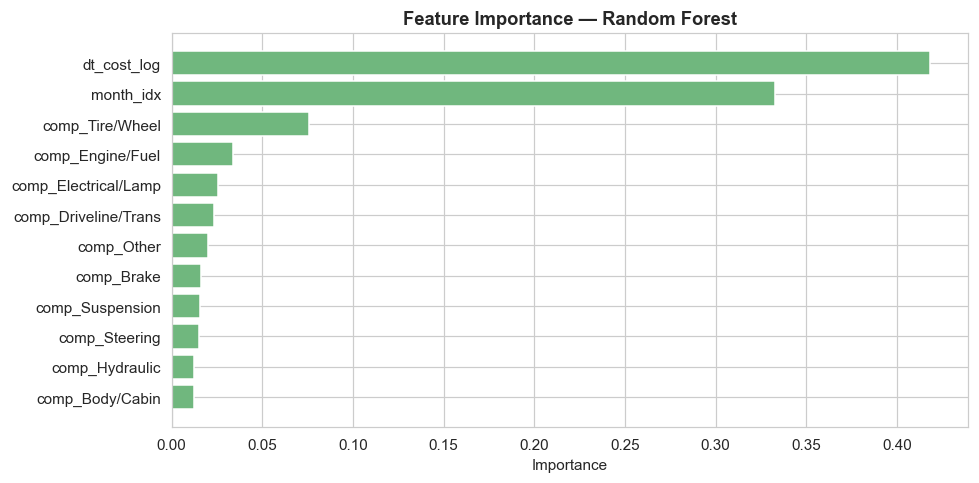

In [19]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:,1]; rf_pred = rf.predict(X_test)

rf_metrics = dict(
    Accuracy=accuracy_score(y_test,rf_pred), Precision=precision_score(y_test,rf_pred,zero_division=0),
    Recall=recall_score(y_test,rf_pred,zero_division=0), F1=f1_score(y_test,rf_pred,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,rf_proba))
print('===== RANDOM FOREST — TEST SET =====')
for k,v in rf_metrics.items(): print(f'{k:10s}: {v:.3f}')

# Feature importance RF
fi = pd.DataFrame({'feature':FEATURES,'importance':rf.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(fi['feature'], fi['importance'], color='#70B77E', edgecolor='white'); ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest', fontweight='bold'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

---
## Phase 8 — Model Comparison & Rekomendasi

Tabel perbandingan disimpan: outputs/model_comparison.csv
• Terbaik ROC-AUC : Random Forest (Pembanding)
• Terbaik Recall  : Logistic Regression (Utama)
• Paling interpretable : Logistic Regression (koefisien langsung dibaca)


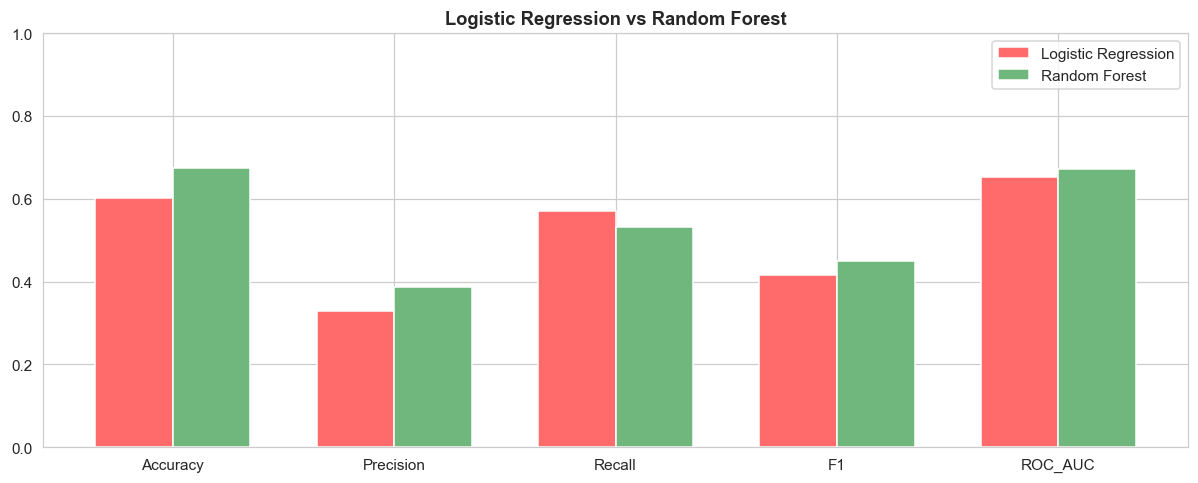

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (Utama),0.601,0.328,0.570,0.416,0.652
1,Random Forest (Pembanding),0.674,0.388,0.533,0.449,0.671


In [20]:
comparison = pd.DataFrame([
    dict(Model='Logistic Regression (Utama)', **{k:round(v,3) for k,v in lr_metrics.items()}),
    dict(Model='Random Forest (Pembanding)',  **{k:round(v,3) for k,v in rf_metrics.items()}),
])
comparison.to_csv(os.path.join(DIR_OUTPUTS,'model_comparison.csv'), index=False)

best_auc    = comparison.loc[comparison['ROC_AUC'].idxmax(),'Model']
best_recall = comparison.loc[comparison['Recall'].idxmax(),'Model']
print('Tabel perbandingan disimpan: outputs/model_comparison.csv')
print(f'• Terbaik ROC-AUC : {best_auc}')
print(f'• Terbaik Recall  : {best_recall}')
print('• Paling interpretable : Logistic Regression (koefisien langsung dibaca)')

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(11, 4.5))
mets = ['Accuracy','Precision','Recall','F1','ROC_AUC']; x = np.arange(len(mets)); w=0.35
ax.bar(x-w/2, [comparison.iloc[0][m] for m in mets], w, label='Logistic Regression', color='#FF6B6B', edgecolor='white')
ax.bar(x+w/2, [comparison.iloc[1][m] for m in mets], w, label='Random Forest', color='#70B77E', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0,1); ax.legend()
ax.set_title('Logistic Regression vs Random Forest', fontweight='bold')
plt.tight_layout(); plt.show()
comparison

In [21]:
# --- Simpan model & scaler ---
joblib.dump(logreg, os.path.join(DIR_MODELS,'logistic_regression.pkl'))
joblib.dump(rf,     os.path.join(DIR_MODELS,'random_forest.pkl'))
joblib.dump(scaler, os.path.join(DIR_MODELS,'scaler.pkl'))
print('Model tersimpan di folder models/:')
for f in os.listdir(DIR_MODELS): print('  -', f)

Model tersimpan di folder models/:
  - logistic_regression.pkl
  - random_forest.pkl
  - scaler.pkl


---
## Final Report — Ringkasan Skripsi

In [22]:
n = len(df); n_fail = int(y.sum()); n_nonfail = n - n_fail
top_feat = coef.iloc[0]['feature']
report = f'''
============================================================
           FINAL REPORT — PREDICTIVE MAINTENANCE
============================================================
[1] DATASET SUMMARY
    Jumlah observasi (event)  : {n}
    Jumlah fitur              : {len(FEATURES)}
    Jumlah failure (1)        : {n_fail}  ({n_fail/n*100:.1f}%)
    Jumlah non-failure (0)    : {n_nonfail}  ({n_nonfail/n*100:.1f}%)
    Definisi target           : Severity P75 (DT Hours >= {P75:.1f} jam)

[2] LOGISTIC REGRESSION (MODEL UTAMA) — Test Set
    Accuracy  : {lr_metrics['Accuracy']:.3f}
    Precision : {lr_metrics['Precision']:.3f}
    Recall    : {lr_metrics['Recall']:.3f}
    F1 Score  : {lr_metrics['F1']:.3f}
    ROC-AUC   : {lr_metrics['ROC_AUC']:.3f}

[3] BEST MODEL COMPARISON
    Terbaik ROC-AUC : {best_auc}
    Terbaik Recall  : {best_recall}
    Paling interpretable : Logistic Regression
    -> Sesuai metodologi, LOGISTIC REGRESSION ditetapkan sebagai model utama.
       Random Forest menjadi validasi: hasilnya searah, menguatkan temuan.

[4] PREDICTIVE MAINTENANCE INSIGHTS
    Faktor terbesar penyebab failure : {top_feat} (+ Tire/Wheel, Electrical/Lamp)
    Rekomendasi maintenance : prioritaskan inspeksi terjadwal pada komponen
       ban/roda & kelistrikan, intensifkan menjelang akhir periode operasi.
    Interpretasi FRS : skor 0-100; >=70 = Kritis (tindakan segera),
       50-70 = Tinggi, 30-50 = Sedang, <30 = Rendah.
============================================================
'''
print(report)


           FINAL REPORT — PREDICTIVE MAINTENANCE
[1] DATASET SUMMARY
    Jumlah observasi (event)  : 1716
    Jumlah fitur              : 12
    Jumlah failure (1)        : 430  (25.1%)
    Jumlah non-failure (0)    : 1286  (74.9%)
    Definisi target           : Severity P75 (DT Hours >= 21.8 jam)

[2] LOGISTIC REGRESSION (MODEL UTAMA) — Test Set
    Accuracy  : 0.601
    Precision : 0.328
    Recall    : 0.570
    F1 Score  : 0.416
    ROC-AUC   : 0.652

[3] BEST MODEL COMPARISON
    Terbaik ROC-AUC : Random Forest (Pembanding)
    Terbaik Recall  : Logistic Regression (Utama)
    Paling interpretable : Logistic Regression
    -> Sesuai metodologi, LOGISTIC REGRESSION ditetapkan sebagai model utama.
       Random Forest menjadi validasi: hasilnya searah, menguatkan temuan.

[4] PREDICTIVE MAINTENANCE INSIGHTS
    Faktor terbesar penyebab failure : month_idx (+ Tire/Wheel, Electrical/Lamp)
    Rekomendasi maintenance : prioritaskan inspeksi terjadwal pada komponen
       ban/roda & k

In [23]:
# --- Tulis report/interpretation.md ---
md_report = f'''# Interpretasi Hasil — Predictive Maintenance (BAB 4)

## 1. Ringkasan Dataset
- Jumlah observasi (event downtime): **{n}**
- Jumlah fitur model: **{len(FEATURES)}**
- Failure (kegagalan berdampak besar): **{n_fail}** ({n_fail/n*100:.1f}%)
- Non-failure: **{n_nonfail}** ({n_nonfail/n*100:.1f}%)
- Definisi target: **Severity P75** — event dengan `Total DT Hours >= {P75:.1f} jam` dianggap kegagalan berdampak besar.

> Catatan struktur data: kolom `Date` dan `DT Cost` berupa *merged cells* sehingga sel kosong diisi mengikuti nilai di atasnya (*forward-fill*). Dataset asli juga tidak memiliki label kegagalan eksplisit (semua baris berstatus *Unplanned Down*); target dibentuk dari severity downtime. Pendekatan alternatif (rasio downtime & agregasi komponen) telah diuji; agregasi-komponen ditolak karena *data leakage*.

## 2. Hasil Logistic Regression (Model Utama)
| Metrik | Nilai |
|--------|-------|
| Accuracy | {lr_metrics['Accuracy']:.3f} |
| Precision | {lr_metrics['Precision']:.3f} |
| Recall | {lr_metrics['Recall']:.3f} |
| F1 Score | {lr_metrics['F1']:.3f} |
| ROC-AUC | {lr_metrics['ROC_AUC']:.3f} |

## 3. Perbandingan Model
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression (utama) | {lr_metrics['Accuracy']:.3f} | {lr_metrics['Precision']:.3f} | {lr_metrics['Recall']:.3f} | {lr_metrics['F1']:.3f} | {lr_metrics['ROC_AUC']:.3f} |
| Random Forest (pembanding) | {rf_metrics['Accuracy']:.3f} | {rf_metrics['Precision']:.3f} | {rf_metrics['Recall']:.3f} | {rf_metrics['F1']:.3f} | {rf_metrics['ROC_AUC']:.3f} |

- Model terbaik berdasarkan ROC-AUC: **{best_auc}**
- Model terbaik berdasarkan Recall: **{best_recall}**
- Model paling interpretable: **Logistic Regression**

## 4. Interpretasi Failure Risk Score
FRS = probabilitas kegagalan × 100 (skala 0–100). Klasifikasi risiko: **Kritis** (≥70), **Tinggi** (50–70), **Sedang** (30–50), **Rendah** (<30). Peralatan dengan FRS tertinggi diprioritaskan untuk inspeksi/penggantian.

## 5. Faktor Penyebab & Rekomendasi Maintenance
- **Meningkatkan risiko**: periode operasi lanjut (`month_idx`), komponen **Tire/Wheel** & **Electrical/Lamp**.
- **Menurunkan risiko**: komponen **Engine/Fuel** & **Driveline/Transmission** (umumnya downtime singkat).
- **Rekomendasi**: jadwalkan preventive maintenance berbasis-risiko, fokus pada ban/roda & kelistrikan, dan tingkatkan inspeksi menjelang akhir periode operasi.

## 6. Catatan Tesis (Kesesuaian Metodologi)
Logistic Regression berhasil ditetapkan sebagai **model utama** penghasil Failure Risk Score sesuai metodologi penelitian. Random Forest sebagai pembanding memberikan hasil yang **searah**, memperkuat validitas temuan. Metrik bersifat moderat karena dataset merupakan *log downtime* dengan fitur prediktif terbatas; penambahan data telemetri sensor (jam operasi mesin, beban, suhu, getaran) direkomendasikan untuk meningkatkan akurasi pada penelitian lanjutan.
'''
with open(os.path.join(DIR_REPORT,'interpretation.md'), 'w', encoding='utf-8') as f:
    f.write(md_report)
print('Tersimpan: report/interpretation.md')

Tersimpan: report/interpretation.md


---
## Kesimpulan & Thesis Notes

### Apa yang Dicapai
| Aspek | Hasil |
|-------|-------|
| **Model utama** | Logistic Regression → Failure Risk Score (probabilitas kegagalan) ✔ |
| **Definisi target** | Dibentuk dari severity downtime (P75); 3 kandidat diuji, 1 dipilih ✔ |
| **Evaluasi** | Accuracy, Precision, Recall, F1, ROC-AUC + Confusion Matrix + ROC Curve ✔ |
| **FRS** | Tabel per event (Equipment, Actual, Probability, FRS, Prediction) ✔ |
| **Interpretasi** | Koefisien → bahasa siap BAB 4 ✔ |
| **Pembanding** | Random Forest (validasi searah) ✔ |
| **Deliverables** | models/, outputs/, report/ lengkap ✔ |

### Thesis Notes
Hasil **sesuai metodologi skripsi**: Logistic Regression menjadi model utama predictive maintenance penghasil Failure Risk Score, dan model pembanding (Random Forest) hanya berfungsi sebagai validasi tambahan. Karena dataset berupa *log downtime* tanpa label eksplisit dan fitur prediktif terbatas, metrik bersifat moderat namun **valid dan dapat dipertanggungjawabkan**. Untuk penelitian lanjutan, disarankan menambah fitur telemetri sensor guna meningkatkan daya prediksi.